### 확률적 경사 하강법
- 손실함수 : 에러율 측정 (Y - Y^)
- Epoch : 훈련데이터를 다 사용하였을 경우의 단계 
- mini batch
- 분류 : 로지스틱 손실함수, 이진크로스엔트로피 손실함수 

In [4]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [5]:
fish = pd.read_csv("../Data/fishes.csv")
fish.head()

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


Species <- [Weight, Length, Diagonal. Height, Width]   

In [6]:
# species 종류
fish.Species.value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

### Feature와 Target 

In [7]:
# Feature
fish_input = fish.iloc[:,1:].to_numpy()
fish_input[:5]

array([[242.    ,  25.4   ,  30.    ,  11.52  ,   4.02  ],
       [290.    ,  26.3   ,  31.2   ,  12.48  ,   4.3056],
       [340.    ,  26.5   ,  31.1   ,  12.3778,   4.6961],
       [363.    ,  29.    ,  33.5   ,  12.73  ,   4.4555],
       [430.    ,  29.    ,  34.    ,  12.444 ,   5.134 ]])

In [8]:
# Target
fish_target = fish.iloc[:,0].to_numpy()
fish_target[:5]

array(['Bream', 'Bream', 'Bream', 'Bream', 'Bream'], dtype=object)

### Train과 Test

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
train_input, test_input, train_target, test_target = \
                        train_test_split(
                            fish_input, 
                            fish_target,
                            random_state=42
                        )

### 

### 표준화 시키기 
: 경사하강법을 사용하는 경우에는 샘플의 크기 때문에 경사의 각도가 바뀔수 있다. 

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

----
### 확률적 경사하강법의 분류 알고리즘 적용

In [13]:
from sklearn.linear_model import SGDClassifier

In [14]:
sc = SGDClassifier(
            loss='log_loss',  # 로지스틱 손실함수 
            max_iter=10,
            random_state=42
)

In [15]:
sc.fit(train_scaled, train_target)

SGDClassifier(loss='log_loss', max_iter=10, random_state=42)

In [16]:
print("Train :", sc.score(train_scaled, train_target))
print("Test  :", sc.score(test_scaled, test_target))

Train : 0.773109243697479
Test  : 0.775


In [17]:
sc.partial_fit(train_scaled, train_target)
print("Train :", sc.score(train_scaled, train_target))
print("Test  :", sc.score(test_scaled, test_target))

Train : 0.8151260504201681
Test  : 0.85


### Epoch / 과대적합(Overfitting) / 과소적합(Underfitting)  
- 조기종료(Early Stopping) : 적합하 Epoch의 위치를 찾으면 종료한다.  
- 규제 값이 작아지면 과대적합이 된다. 

In [18]:
import numpy as np

In [39]:
sc = SGDClassifier(
        loss='log_loss',
        random_state=42
)

train_score = []
test_score = []

classes = np.unique(train_target)
classes

array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
      dtype=object)

In [40]:
for _ in range(300):
    sc.partial_fit(train_scaled, train_target, classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

In [41]:
# 그래프로 그려보기
import matplotlib.pyplot as plt

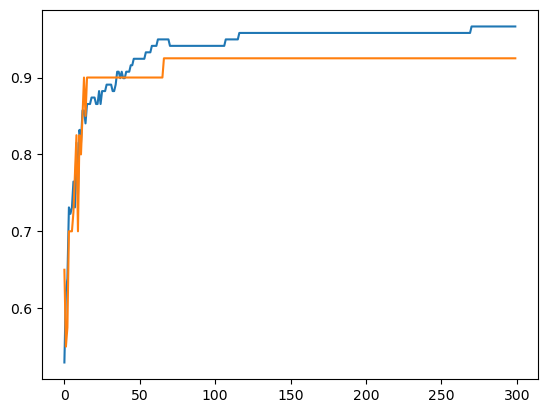

In [42]:
plt.plot(train_score)
plt.plot(test_score)
plt.show()

> 100정도의 Epoch횟수가 좋은 것 같다.

---

In [27]:
sc = SGDClassifier(
        loss='log_loss',
        max_iter=100,
        random_state=42,
        tol=None # 조기종료 사용안함, 사용하는 경우느 반복기간 동안 최적의 손실값이 큰 경우 종료한다. 
)

# 학습하기
sc.fit(train_scaled, train_target)

SGDClassifier(loss='log_loss', max_iter=100, random_state=42, tol=None)

In [28]:
print("Train :", sc.score(train_scaled, train_target))
print("Test  :", sc.score(test_scaled, test_target))

Train : 0.957983193277311
Test  : 0.925


---
#### 조기종료 시점 적용

In [44]:
sc = SGDClassifier(
        loss='log_loss',
        max_iter=100,
        random_state=42,
        tol=0.0001 # 사용하는 경우는 반복기간 동안 최적의 손실값이 큰 경우 종료한다. 
)

# 학습하기
sc.fit(train_scaled, train_target)

print("Train :", sc.score(train_scaled, train_target))
print("Test  :", sc.score(test_scaled, test_target))

Train : 0.8403361344537815
Test  : 0.8


---
### SVM을 이용하는 확률적 경사 하강법

In [45]:
# 조기 종료가 없는 경우
sc = SGDClassifier(
        loss='hinge', 
        max_iter=100,
        random_state=42,
        tol=None # 사용하는 경우는 반복기간 동안 최적의 손실값이 큰 경우 종료한다. 
)

# 학습하기
sc.fit(train_scaled, train_target)

print("Train :", sc.score(train_scaled, train_target))
print("Test  :", sc.score(test_scaled, test_target))

Train : 0.9495798319327731
Test  : 0.925


In [46]:
# 조기 종료 시점 적용
sc = SGDClassifier(
        loss='hinge', 
        max_iter=100,
        random_state=42,
        tol=0.001 # 사용하는 경우는 반복기간 동안 최적의 손실값이 큰 경우 종료한다. 
)

# 학습하기
sc.fit(train_scaled, train_target)

print("Train :", sc.score(train_scaled, train_target))
print("Test  :", sc.score(test_scaled, test_target))

Train : 0.907563025210084
Test  : 0.925
